# Mathematics of Machine Learning

This notebook covers the fundamental mathematical concepts that power machine learning algorithms. We will explore key topics across:
1. **Linear Algebra**: The language of data structures (vectors, matrices, eigenvalues).
2. **Calculus**: The engine of optimization (derivatives, partial derivatives, gradient descent).
3. **Probability & Statistics**: The tool for handling uncertainty and modeling data distributions.

---

## 1. Linear Algebra

Linear Algebra allows us to represent and manipulate datasets. In machine learning:
- **Vectors** represent individual data samples (features).
- **Matrices** represent entire datasets where rows are samples and columns are features.

### 1.1 Vector Dot Product
The dot product of two vectors $u = [u_1, u_2, \dots, u_n]$ and $v = [v_1, v_2, \dots, v_n]$ is a scalar:
$$u \cdot v = \sum_{i=1}^n u_i v_i = u^T v$$
In machine learning, the dot product represents the projection of one vector onto another and is the core of computing weighted sums (e.g., in linear regression and neural networks: $z = w^T x + b$).

### 1.2 Matrix Multiplication
For two matrices $A$ (size $m \times n$) and $B$ (size $n \times p$), their product $C = AB$ is an $m \times p$ matrix where:
$$C_{ij} = \sum_{k=1}^n A_{ik} B_{kj}$$
This represents applying linear transformations in batch.

### 1.3 Matrix Transpose & Inverse
- **Transpose ($A^T$)**: Flips the matrix over its diagonal ($A^T_{ij} = A_{ji}$).
- **Inverse ($A^{-1}$)**: The matrix that yields the identity matrix when multiplied by the original matrix ($A A^{-1} = I$). Only square matrices can have an inverse.

### 1.4 Eigenvalues & Eigenvectors
An eigenvector $v$ of a square matrix $A$ is a non-zero vector that changes only by a scalar factor $\lambda$ (the eigenvalue) when $A$ is applied:
$$A v = \lambda v$$
This is the foundation of **Principal Component Analysis (PCA)**, where eigenvectors correspond to the principal axes of data variance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define vectors
u = np.array([3, 4])
v = np.array([1, 2])

# Compute dot product
dot_product = np.dot(u, v)
print(f"Vector u: {u}")
print(f"Vector v: {v}")
print(f"Dot Product (u . v): {dot_product}")

Vector u: [3 4]
Vector v: [1 2]
Dot Product (u . v): 11


In [2]:
# Define matrices
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

# Matrix multiplication
C = A @ B  # equivalent to np.dot(A, B)
print(f"Matrix A:\n{A}\n")
print(f"Matrix B:\n{B}\n")
print(f"Matrix Multiplication (A @ B):\n{C}\n")
print(f"Transpose of A (A.T):\n{A.T}")

Matrix A:
[[1 2]
 [3 4]]

Matrix B:
[[5 6]
 [7 8]]

Matrix Multiplication (A @ B):
[[19 22]
 [43 50]]

Transpose of A (A.T):
[[1 3]
 [2 4]]


In [3]:
# Eigenvalues and Eigenvectors (used in PCA)
cov_matrix = np.array([[3, 1], [1, 3]])  # Symmetric covariance-like matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print(f"Covariance Matrix:\n{cov_matrix}\n")
print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors (columns):\n{eigenvectors}")

Covariance Matrix:
[[3 1]
 [1 3]]

Eigenvalues: [4. 2.]
Eigenvectors (columns):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


## 2. Calculus

Calculus provides the tools to train machine learning models by finding the parameter values that minimize a **loss function**.

### 2.1 Derivatives & Gradients
- **Derivative ($f'(x)$)**: Measures the rate of change of a function with respect to a single variable.
- **Partial Derivative ($\frac{\partial f}{\partial x_i}$)**: Measures the rate of change with respect to one variable while holding others constant.
- **Gradient ($\nabla f$)**: The vector of all partial derivatives of a multi-variable function:
$$\nabla f(x, y) = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix}$$
The gradient points in the direction of the steepest ascent of the function.

### 2.2 Gradient Descent
To minimize a loss function $J(w)$, we update the weights $w$ in the opposite direction of the gradient:
$$w \leftarrow w - \alpha \nabla J(w)$$
where $\alpha$ is the **learning rate** (step size).

In [4]:
# Step-by-step implementation of Gradient Descent
# Objective: Minimize f(x) = x^2 - 4x + 4
# Derivative (Gradient): df/dx = 2x - 4 (minimum is at x = 2)

def f(x):
    return x**2 - 4*x + 4

def df(x):
    return 2*x - 4

# Gradient Descent Hyperparameters
learning_rate = 0.1
epochs = 15
x = 9.0  # Initial weight guess

x_history = [x]
y_history = [f(x)]

print("Starting Gradient Descent optimization...")
for epoch in range(epochs):
    grad = df(x)
    x = x - learning_rate * grad
    x_history.append(x)
    y_history.append(f(x))
    print(f"Epoch {epoch+1:02d}: x = {x:.4f}, f(x) = {f(x):.4f}")

Starting Gradient Descent optimization...
Epoch 01: x = 7.6000, f(x) = 31.3600
Epoch 02: x = 6.4800, f(x) = 20.0704
Epoch 03: x = 5.5840, f(x) = 12.8451
Epoch 04: x = 4.8672, f(x) = 8.2208
Epoch 05: x = 4.2938, f(x) = 5.2613
Epoch 06: x = 3.8350, f(x) = 3.3673
Epoch 07: x = 3.4680, f(x) = 2.1550
Epoch 08: x = 3.1744, f(x) = 1.3792
Epoch 09: x = 2.9395, f(x) = 0.8827
Epoch 10: x = 2.7516, f(x) = 0.5649
Epoch 11: x = 2.6013, f(x) = 0.3616
Epoch 12: x = 2.4810, f(x) = 0.2314
Epoch 13: x = 2.3848, f(x) = 0.1481
Epoch 14: x = 2.3079, f(x) = 0.0948
Epoch 15: x = 2.2463, f(x) = 0.0607


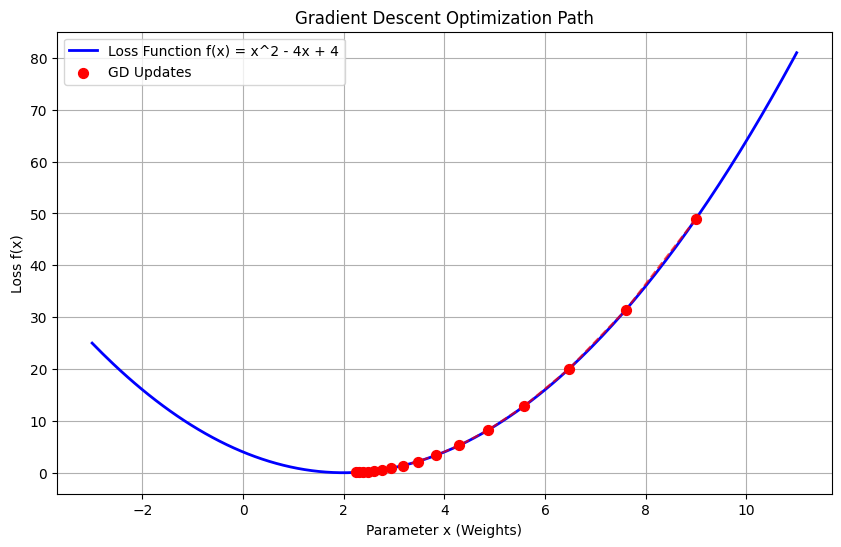

In [5]:
# Visualizing the Gradient Descent Optimization Path
x_curve = np.linspace(-3, 11, 200)
y_curve = f(x_curve)

plt.figure(figsize=(10, 6))
plt.plot(x_curve, y_curve, label="Loss Function f(x) = x^2 - 4x + 4", color="blue", linewidth=2)
plt.scatter(x_history, y_history, color="red", s=50, zorder=3, label="GD Updates")
plt.plot(x_history, y_history, color="red", linestyle="--", alpha=0.7)
plt.title("Gradient Descent Optimization Path")
plt.xlabel("Parameter x (Weights)")
plt.ylabel("Loss f(x)")
plt.legend()
plt.grid(True)
plt.show()

## 3. Probability & Statistics

Probability and statistics help us deal with noise, estimate variables, and model data distributions.

### 3.1 Mean, Variance, & Covariance
- **Mean (Expected Value, $\mu$)**: The average value of a distribution.
- **Variance ($\sigma^2$)**: Measures the spread of data points around the mean.
- **Covariance**: Measures how two random variables change together:
$$\text{Cov}(X, Y) = \mathbb{E}[(X - \mu_X)(Y - \mu_Y)]$$
- **Correlation**: Standardized covariance ranging from -1 to 1.

### 3.2 Bayes' Theorem
Computes conditional probability (updates belief based on new evidence):
$$P(A|B) = \frac{P(B|A) P(A)}{P(B)}$$
This is the foundation of **Naive Bayes** classifiers used in text classification.

In [6]:
# Study hours vs Exam scores
study_hours = np.array([1, 2, 4, 6, 8, 10])
exam_scores = np.array([45, 52, 68, 80, 85, 98])

mean_hours = np.mean(study_hours)
std_hours = np.std(study_hours)
cov_matrix = np.cov(study_hours, exam_scores)
corr_matrix = np.corrcoef(study_hours, exam_scores)

print(f"Mean Study Hours: {mean_hours:.2f}")
print(f"Std Study Hours: {std_hours:.2f}")
print(f"Covariance Matrix:\n{cov_matrix}\n")
print(f"Correlation Coefficient: {corr_matrix[0, 1]:.4f}")

Mean Study Hours: 5.17
Std Study Hours: 3.18
Covariance Matrix:
[[ 12.16666667  69.93333333]
 [ 69.93333333 410.26666667]]

Correlation Coefficient: 0.9898


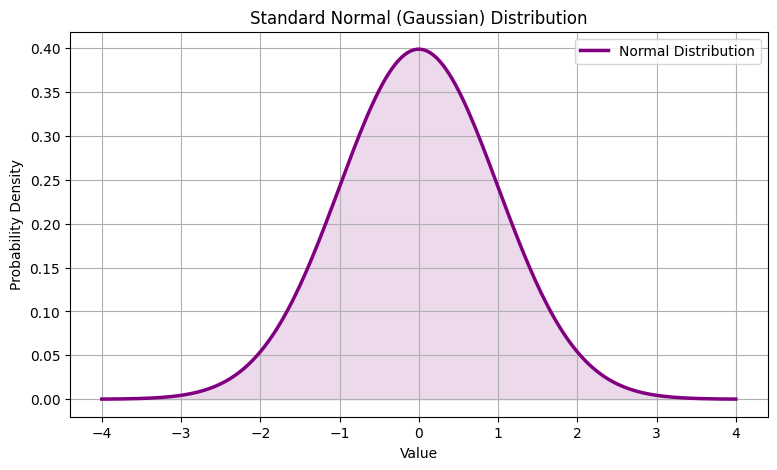

In [7]:
# Plotting a Standard Normal Distribution (Gaussian)
mu, sigma = 0, 1
x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(- (x_norm - mu)**2 / (2 * sigma**2))

plt.figure(figsize=(9, 5))
plt.plot(x_norm, pdf, color="purple", linewidth=2.5, label="Normal Distribution")
plt.fill_between(x_norm, pdf, color="purple", alpha=0.15)
plt.title("Standard Normal (Gaussian) Distribution")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()